# Benchmark Model 3: Both Coordinates & Velocities (`model_bench_combined.ipynb`)

This notebook trains a PyTorch LSTM model using **BOTH Landmark Coordinates and Transition Velocities** (16 features per step across 5 frame timesteps: $N, 5, 16$).

## 1. Imports & Hyperparameters Setup

In [35]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Set random seeds for reproducibility
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Hyperparameters
SEQ_LEN = 5          # 5 frame timesteps
FEATURE_DIM = 16     # 8 coordinates + 8 transition velocities per step
BATCH_SIZE = 32
LEARNING_RATE = 0.001
HIDDEN_UNITS = 64
DROPOUT = 0.2
EPOCHS = 40

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Load & Prepare Datasets (Both Coordinates & Velocities)

In [36]:
def extract_combined_features(csv_path):
    df = pd.read_csv(csv_path)
    n_samples = len(df)
    X = np.zeros((n_samples, 5, 16), dtype=np.float32)
    
    for k in range(1, 6):
        coord_cols = [
            f"wrist{k}_x", f"wrist{k}_y",
            f"mcp{k}_x", f"mcp{k}_y",
            f"pip{k}_x", f"pip{k}_y",
            f"dip{k}_x", f"dip{k}_y"
        ]
        coords_vals = df[coord_cols].fillna(0.0).values.astype(np.float32)
        
        if k == 1:
            vel_vals = np.zeros((n_samples, 8), dtype=np.float32)
        else:
            v_idx = k - 1
            vel_cols = [
                f"wrist{v_idx}_vx", f"wrist{v_idx}_vy",
                f"mcp{v_idx}_vx", f"mcp{v_idx}_vy",
                f"pip{v_idx}_vx", f"pip{v_idx}_vy",
                f"dip{v_idx}_vx", f"dip{v_idx}_vy"
            ]
            vel_vals = df[vel_cols].fillna(0.0).values.astype(np.float32)
            
        step_vals = np.hstack([coords_vals, vel_vals])
        X[:, k - 1, :] = step_vals
        
    target_col = "touch_finger" if "touch_finger" in df.columns else "touch"
    y = df[target_col].astype(str).str.strip().str.lower().isin(["1", "true", "t", "yes", "y"]).values.astype(np.float32)
    y = y.reshape(-1, 1)
    
    return X, y

TRAIN_CSV = "./data/training_data.csv"
TEST_CSV = "./data/test_data.csv"

X_train_np, y_train_np = extract_combined_features(TRAIN_CSV)
X_test_np, y_test_np = extract_combined_features(TEST_CSV)

# Normalize using StandardScaler
scaler = StandardScaler()
N_tr, T, C = X_train_np.shape
N_te, _, _ = X_test_np.shape

X_train_flat = X_train_np.reshape(N_tr, -1)
X_test_flat = X_test_np.reshape(N_te, -1)

X_train_scaled = scaler.fit_transform(X_train_flat).reshape(N_tr, T, C)
X_test_scaled = scaler.transform(X_test_flat).reshape(N_te, T, C)

X_train = torch.from_numpy(X_train_scaled).type(torch.float32)
y_train = torch.from_numpy(y_train_np).type(torch.float32)
X_test = torch.from_numpy(X_test_scaled).type(torch.float32)
y_test = torch.from_numpy(y_test_np).type(torch.float32)

print(f"X_train shape (Both Coords & Velocities): {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape  (Both Coords & Velocities): {X_test.shape},  y_test shape:  {y_test.shape}")

X_train shape (Both Coords & Velocities): torch.Size([2122, 5, 16]), y_train shape: torch.Size([2122, 1])
X_test shape  (Both Coords & Velocities): torch.Size([332, 5, 16]),  y_test shape:  torch.Size([332, 1])


## 3. DataLoader Setup

In [37]:
class CombinedDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(CombinedDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(CombinedDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

## 4. LSTM Architecture

In [38]:
class CombinedLSTM(nn.Module):
    def __init__(self, input_features=16, hidden_units=32, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_features, hidden_size=hidden_units, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_units, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1)
        )
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.classifier(lstm_out[:, -1, :])

model_combined = CombinedLSTM(input_features=FEATURE_DIM, hidden_units=HIDDEN_UNITS).to(device)
print(model_combined)

CombinedLSTM(
  (lstm): LSTM(16, 64, num_layers=2, batch_first=True, dropout=0.2)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 5. Training Loop

In [39]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_combined.parameters(), lr=LEARNING_RATE)

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(1, EPOCHS + 1):
    model_combined.train()
    tr_loss, tr_acc = 0.0, 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        logits = model_combined(X_b)
        loss = loss_fn(logits, y_b)
        preds = torch.round(torch.sigmoid(logits))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        tr_loss += loss.item() * len(X_b)
        tr_acc += (torch.eq(y_b, preds).sum().item() / len(y_b)) * len(X_b)
        
    train_loss = tr_loss / len(train_loader.dataset)
    train_acc = (tr_acc / len(train_loader.dataset)) * 100.0
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    model_combined.eval()
    te_loss, te_acc = 0.0, 0.0
    with torch.inference_mode():
        for X_b, y_b in test_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits = model_combined(X_b)
            loss = loss_fn(logits, y_b)
            preds = torch.round(torch.sigmoid(logits))
            
            te_loss += loss.item() * len(X_b)
            te_acc += (torch.eq(y_b, preds).sum().item() / len(y_b)) * len(X_b)
            
    test_loss = te_loss / len(test_loader.dataset)
    test_acc = (te_acc / len(test_loader.dataset)) * 100.0
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch: {epoch:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch: 01 | Train Loss: 0.6719 | Train Acc: 58.58% | Test Loss: 0.6213 | Test Acc: 73.19%
Epoch: 05 | Train Loss: 0.3123 | Train Acc: 89.30% | Test Loss: 0.2979 | Test Acc: 89.46%
Epoch: 10 | Train Loss: 0.2656 | Train Acc: 90.20% | Test Loss: 0.2703 | Test Acc: 91.87%
Epoch: 15 | Train Loss: 0.2490 | Train Acc: 90.86% | Test Loss: 0.2986 | Test Acc: 92.17%
Epoch: 20 | Train Loss: 0.2207 | Train Acc: 92.37% | Test Loss: 0.2816 | Test Acc: 92.47%
Epoch: 25 | Train Loss: 0.2044 | Train Acc: 92.32% | Test Loss: 0.3145 | Test Acc: 91.87%
Epoch: 30 | Train Loss: 0.1749 | Train Acc: 93.40% | Test Loss: 0.4225 | Test Acc: 90.66%
Epoch: 35 | Train Loss: 0.1462 | Train Acc: 94.39% | Test Loss: 0.4946 | Test Acc: 89.76%
Epoch: 40 | Train Loss: 0.1153 | Train Acc: 95.90% | Test Loss: 0.4941 | Test Acc: 88.25%


## 6. Training & Testing Curves

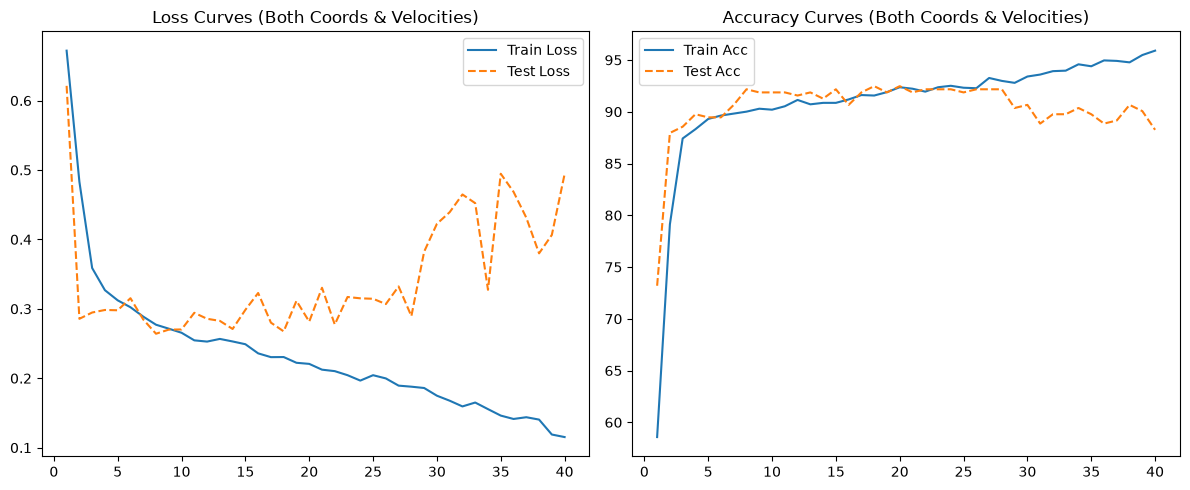

In [40]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), test_losses, label="Test Loss", linestyle="--")
plt.title("Loss Curves (Both Coords & Velocities)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), train_accuracies, label="Train Acc")
plt.plot(range(1, EPOCHS + 1), test_accuracies, label="Test Acc", linestyle="--")
plt.title("Accuracy Curves (Both Coords & Velocities)")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Model Evaluation Analytics (Confusion Matrix & Classification Report)

In [7]:
model_combined.eval()
all_preds, all_targets = [], []
with torch.inference_mode():
    for X_b, y_b in test_loader:
        logits = model_combined(X_b.to(device))
        preds = torch.round(torch.sigmoid(logits)).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(y_b.numpy())
        
all_preds = np.array(all_preds).squeeze()
all_targets = np.array(all_targets).squeeze()
cm = confusion_matrix(all_targets, all_preds)
labels = ["Untouch (0)", "Touch (1)"]

print("\n" + "="*50)
print(" CONFUSION MATRIX (Both Coords & Velocities)")
print("="*50)
print(cm)
print("\nClassification Report:\n", classification_report(all_targets, all_preds, target_names=labels))
print("="*50)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix Heatmap - Both Coords & Velocities")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## 8. Save Model Weights

In [8]:
torch.save(model_combined.state_dict(), "finger_touch_combined.pth")
print("Saved model weights to 'finger_touch_combined.pth'.")